In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the classic Iris Dataset
iris = load_iris()
X = iris.data       # Shape: (150, 4) -> 4D data
y = iris.target     # Shape: (150,) -> 0, 1, or 2 representing the 3 flower species

In [2]:
class PCA:
    def __init__(self):
        self.mean = None
        self.components = None

    def fit(self, X):
        # 1. Calculate the mean of each column (feature) and save it as self.mean
        self.mean = np.mean(X , axis=0)
        # 2. Subtract the mean from X to center the data (X_centered)
        X_centered = np.subtract(X, self.mean)
        # 3. Run SVD on X_centered using np.linalg.svd
        U , S , Vt = np.linalg.svd(X_centered)
        # 4. Extract and store the right singular vectors (V) as self.components
        self.components = Vt.T
        # Hint: np.linalg.svd returns Vt. You need to transpose it to get V!
        # pass

    def transform(self, X, k):
        # 1. Center the input data X using the stored self.mean
        self.mean = np.mean(X )
        X_centered = np.subtract(X, self.mean)
        # 2. Slice self.components to keep only the first k columns
        self.components = self.components[:,:k]
        # 3. Project the centered data onto these k columns using matrix multiplication (@)
        projection = X_centered @ self.components
        # 4. Return the projected (compressed) data matrix
        return projection

In [4]:
pca = PCA()
pca.fit(X)

In [6]:
X_projected = pca.transform(X, k=2)
X_projected.shape

(150, 2)

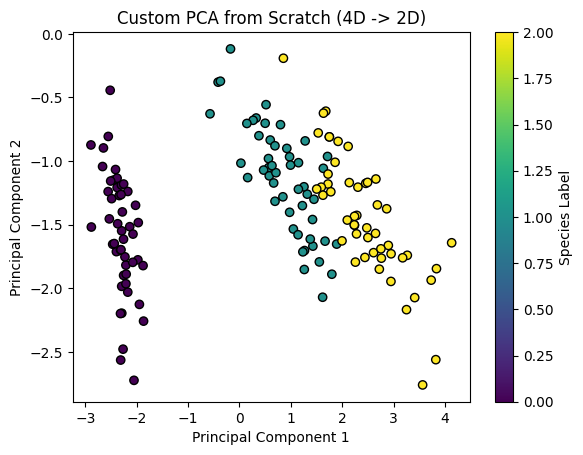

In [7]:
# Scatter plot the 2D projected data
# We color the points using 'y' so we can see if our math grouped the flower species correctly!
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Custom PCA from Scratch (4D -> 2D)')
plt.colorbar(label='Species Label')
plt.show()